- title: Занятие 5
- author: Svetlana Medvedeva
- date: 2026-09-30
- slug: 2026_lpr_lab05
- ipynb_url: download/2026_lpr_lab06.ipynb
- test_link: https://lms.mipt.ru/mod/quiz/view.php?id=219352
- test_comment: Контест для выполнения

# Лабораторное занятие 5

# Основы ООП

**Объектно-ориентированное программирование** (ООП) — это одна из парадигм разработки. Парадигмой называют набор правил и критериев, которые соблюдают разработчики при написании кода.

Суть понятия объектно-ориентированного программирования в том, что все программы, написанные с применением этой парадигмы, состоят из объектов. Каждый объект — это определённая сущность со своими данными и набором доступных действий.

Например, нужно написать для интернет-магазина каталог товаров. Руководствуясь принципами ООП, в первую очередь нужно создать объекты: карточки товаров. Потом заполнить эти карточки данными: названием товара, свойствами, ценой. И потом прописать доступные действия для объектов: обновление, изменение, взаимодействие.

Кроме ООП, существуют и другие парадигмы. Из них наиболее распространена **функциональная**, в которой работают не с объектами, а с функциями. Если использовать функциональную парадигму, чтобы сделать каталог товаров, то начинать нужно не с карточек, а с функций, заполняющих эти карточки. То есть объект будет не отправной точкой, а результатом работы функции.

Обычно написать функцию быстрее, чем создавать объекты и прописывать взаимодействие между ними. Но если объём кода большой, работать с разрозненными функциями сложно.

Центральные понятием в ООП являются объекты.
Объекты, в свою очередь, являются экземплярами классов – с этой точки зрения классы можно назвать шаблонами для создания объектов определенного типа.

Классы определяют:

* структуру данных, которые характеризуют объект;
* свойства (атрибуты) и статус (состояние) объекта;
* операции, которые можно совершать с данными объекта (методы).

Рассмотрим пример класса:

In [1]:
class Car:
    def __init__(self, make, model, year):
        self.make = make
        self.model = model
        self.year = year

**Атрибуты** – это свойства, характеристики объекта.

Атрибуты объекта перечисляют внутри __init__ метода класса – он вызывается каждый раз при создании экземпляра класса. Параметр self создает ссылку на экземпляр класса и позволяет получить доступ к атрибутам и методам объекта. Для создания экземпляра Car достаточно вызвать класс, передавая в скобках значения, соответствующие его атрибутам:

In [2]:
my_car = Car("Toyota", "Corolla", 2023)

После присвоения атрибутам значений к ним мы можем обращаться через выражение название_объекта.атрибут:

In [3]:
print(f'Марка машины {my_car.make},'
      f'\nмодель {my_car.model},'
      f'\nгод выпуска - {my_car.year}'
      )

Марка машины Toyota,
модель Corolla,
год выпуска - 2023


Мы рассмотрели пример простейшего класса: у него нет ни подклассов, ни методов, кроме обязательного __init__.

Метод – это функция, которая определяет поведение объекта.

Проиллюстрируем создание метода на примере класса WashingMachine – здесь методremaining_warranty_time() определяет срок истечения гарантии на стиральную машину:

In [4]:
import datetime

class WashingMachine:
    def __init__(self, brand, model, purchase_date, warranty_length):
        self.brand = brand
        self.model = model
        self.purchase_date = purchase_date
        self.warranty_length = warranty_length

    def remaining_warranty_time(self):
        today = datetime.date.today()
        warranty_end_date = self.purchase_date + datetime.timedelta(days=self.warranty_length)
        remaining_time = warranty_end_date - today
        if remaining_time.days < 0:
            return "Срок действия гарантии истек."
        else:
            return "Срок действия гарантии истекает через {} дней.".format(remaining_time.days)

# создаем объект стиральной машины
my_washing_machine = WashingMachine("LG", "FH4U2VCN2", datetime.date(2022, 5, 7), 1550)

# вызываем метод для проверки срока истечения гарантии
print(my_washing_machine.remaining_warranty_time())

Срок действия гарантии истек.


## Основные принципы объектно-ориентированного программирования:

**Инкапсуляция** - механизм сокрытия деталей реализации класса от других объектов. Достигается путем использования модификаторов доступа public, private и protected, которые соответствуют публичным, приватным и защищенным атрибутам.

*   Private. Приватные члены класса недоступны извне - с ними можно работать только внутри класса.
*   Public. Публичные методы наоборот - открыты для работы снаружи и, как правило, объявляются публичными сразу по-умолчанию.
*   Protected. Доступ к защищенным ресурсам класса возможен только внутри этого класса и также внутри унаследованных от него классов (иными словами, внутри классов-потомков). Больше никто доступа к ним не имеет.

Например, метод для внесения данных в карточку товара должен обязательно быть прописан в классе «Карточка товара». А не в классе «Корзина» или «Каталог товаров».

Такой принцип обеспечивает безопасность и не даёт повредить данные внутри какого-то класса со стороны. Ещё он помогает избежать случайных зависимостей, когда из-за изменения одного объекта что-то ломается в другом.



Сделаем атрибуты title, author и isbn класса Book приватными – теперь доступ к ним возможен только внутри класса:

In [5]:
class Book:
    def __init__(self, title, author, isbn):
        self.__title = title  # приватный
        self.__author = author  # приватный
        self.__isbn = isbn  # приватный

Чтобы получить доступ к этим атрибутам извне класса, мы определяем методы getter и setter, которые обеспечивают контролируемый доступ к атрибутам:

In [6]:
class Book:
    def __init__(self, title, author, isbn):
        self.genre = 'Fantasy'
        self.__title = title  # приватный
        self.__author = author  # приватный
        self.__isbn = isbn  # приватный

    def get_title(self):
        return self.__title

    def set_title(self, title):
        self.__title = title

    def get_author(self):
        return self.__author

    def set_author(self, author):
        self.__author = author

    def get_isbn(self):
        return self.__isbn

    def set_isbn(self, isbn):
        self.__isbn = isbn

In [7]:
book0 = Book("Властелин колец", "Дж. Р. Р. Толкина", "558-0743553565")
book0.genre

'Fantasy'

В этом примере методы get_title(), get_author() и get_isbn() являются получающими методами (геттерами), которые позволяют нам получать значения приватных атрибутов извне класса. Методы set_title(), set_author() и set_isbn() – устанавливающие методы (сеттеры), которые позволяют нам устанавливать значения частных атрибутов извне класса.

Создадим экземпляр объекта и попытаемся получить доступ к его названию с помощью обычного метода:

In [8]:
book1 = Book("Властелин колец", "Дж. Р. Р. Толкина", "558-0743553565")

# пытаемся получить доступ к приватному атрибуту
print(book1.__title)

AttributeError: 'Book' object has no attribute '__title'

Воспользуемся геттерами:

In [ ]:
print(book1.get_title())
print(book1.get_author())
print(book1.get_isbn())

Властелин колец
Дж. Р. Р. Толкина
558-0743553565


Изменим название с помощью сеттера и выведем результат:

In [ ]:
book1.set_title("Гарри Поттер")
print(book1.get_title())

Гарри Поттер


In [ ]:
print(book1.get_title())

Гарри Поттер


## Наследование

**Наследование** - процесс создания нового класса на основе существующего класса. Новый класс, называемый подклассом или производным классом, наследует свойства и методы существующего класса, называемого суперклассом или базовым классом.

Написание кода с использованием ООП выглядит следующим образом:

● Класс с определёнными свойствами;
● Подкласс на его основе, который берёт свойства класса и добавляет свои;
● Объект подкласса, который также копирует его свойства и добавляет свои.

Каждый дочерний элемент наследует методы и атрибуты, прописанные в родительском. Он может использовать их все, отбросить часть или добавить новые. При этом заново прописывать эти атрибуты и методы не нужно.

Для иллюстрации концепции наследования мы определим класс Publication, который имеет свойства, общие для всех публикаций – title, author и year, а также общий метод display():

In [ ]:
class Publication:
    def __init__(self, title, author, year):
        self.title = title
        self.author = author
        self.year = year

    def display(self):
        print("Название:", self.title)
        print("Автор:", self.author)
        print("Год выпуска:", self.year)

Теперь создадим два подкласса Book и Magazine, которые наследуют все свойства и методы от класса Publication, и кроме того, имеют свои атрибуты. Подкласс Book добавляет свойство isbn и переопределяет метод display() для включения свойства isbn. Подкласс Magazine добавляет свойство issue_number (номер выпуска) и переопределяет методdisplay()для включения свойства issue_number:

In [ ]:
class Book(Publication):
    def __init__(self, title, author, year, isbn):
        super().__init__(title, author, year)
        self.isbn = isbn

    def display(self):
        super().display()
        print("ISBN:", self.isbn)

class Magazine(Publication):
    def __init__(self, title, author, year, issue_number):
        super().__init__(title, author, year)
        self.issue_number = issue_number

    def display(self):
        super().display()
        print("Номер выпуска:", self.issue_number)

Теперь, если мы создадим экземпляр класса Book или класса Magazine, мы сможем вызвать метод display()для отображения свойств объекта. Сначала будет вызван метод display() подкласса (Book или Magazine), который в свою очередь вызовет метод display()суперкласса Publication с помощью функции super(). Это позволяет нам повторно использовать код суперкласса и избежать дублирования кода в подклассах:



In [ ]:
# создаем объект книги
book1 = Book("Властелин колец", "Дж. Р. Р. Толкина", 2019, "112-3333273566")

# создаем объект выпуска журнала
magazine1 = Magazine("Вокруг света", "коллектив авторов", 2023, 3)

# выводим информацию о книге и номере журнала
book1.display()
magazine1.display()

Название: Властелин колец
Автор: Дж. Р. Р. Толкина
Год выпуска: 2019
ISBN: 112-3333273566
Название: Вокруг света
Автор: коллектив авторов
Год выпуска: 2023
Номер выпуска: 3


## Полиморфизм

Один и тот же метод может работать по-разному в зависимости от объекта, где он вызван, и данных, которые ему передали. Например, метод «Удалить» при вызове в корзине удалит товар только из корзины, а при вызове в карточке товара — удалит саму карточку из каталога.

То же самое с объектами. Можно использовать их публичные методы и атрибуты в других функциях и быть уверенным, что всё сработает нормально.

### Полиморфизм оператора сложения

In [ ]:
num1 = 1
num2 = 2
print(num1 + num2)

3


In [ ]:
str1 = "Python"
str2 = "Programming"
print(str1+" "+str2)

Python Programming


In [ ]:
lst1 = [1, 2, 3, 4]
lst2 = [5, 6, 7]
print(lst1+lst2)

[1, 2, 3, 4, 5, 6, 7]


In [ ]:
'1223' + 12

TypeError: can only concatenate str (not "int") to str

### Полиморфизм функций

In [ ]:
print(len("Python"))
print(len(["Python", "Java", "C"]))
print(len({"1": "a", "2": "b", "3": "c"}))

6
3
3


### Полиморфизм в методах класса

In [ ]:
class Cat:
    def __init__(self, name, age):
        self.name = name
        self.age = age

    def info(self):
        print(f"I am a cat. My name is {self.name}. I am {self.age} years old.")

    def make_sound(self):
        print("Meow")


class Dog:
    def __init__(self, name, age):
        self.name = name
        self.age = age

    def info(self):
        print(f"I am a dog. My name is {self.name}. I am {self.age} years old.")

    def make_sound(self):
        print("Bark")


cat1 = Cat("Kitty", 2.5)
dog1 = Dog("Fluffy", 4)

for animal in (cat1, dog1):
    animal.make_sound()
    animal.info()
    animal.make_sound()

Meow
I am a cat. My name is Kitty. I am 2.5 years old.
Meow
Bark
I am a dog. My name is Fluffy. I am 4 years old.
Bark


## Правила оформления кода (PEP8)

Единообразие, наглядность и информативность — это основа PEP8.

Основные правила:

* В Python внутренние блоки кода выделяются отступами, а не специальными разделителями. Размер отступа — четыре пробела, табуляция не используется.

* Аргументы функций переносятся на следующую строку и выравниваются, если строка слишком длинная:
`def long_func (arg_one, arg_two,
                arg_three, arg_four)`
                
* Знаки операций ставятся после переноса строки:
`total_users = (currently_online
+ offline_but_active
+ offline_inactive
- duplicate_accounts
- banned)`

* Между функциями верхнего уровня и классами вставляются две пустые строки. Между определениями методов в классе — одна пустая строка. Разрешается добавлять пустые строки между логическими секциями.

* По правильно названной переменной или функции сразу понятно, зачем они нужны: в first_name лежит имя, а calculate_employee_salary() считает зарплату сотрудника.

In [ ]:
# Правильно

first_name = 'Ivan'
last_name = 'Ivanov'

def plus_one (x):
    return x + 1

# Неправильно

fnm = 'Ivan'
lnm = 'Ivanov'

# Plus 1? Phase 1? Point 1?
def p1 (x):
    return x + 1

Рекомендации по оформлению кода


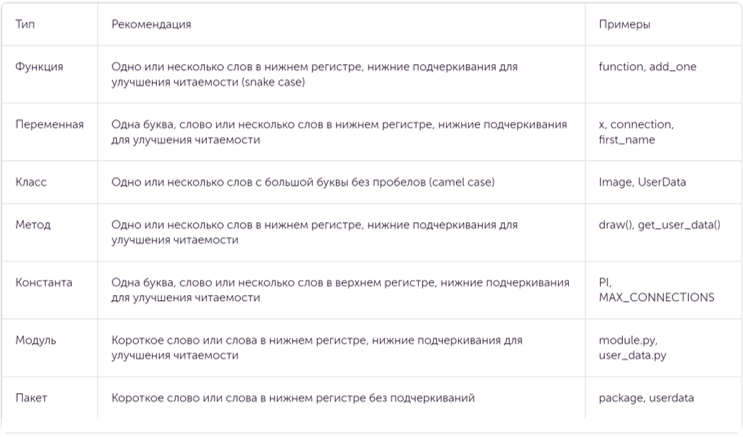

In [ ]:
from IPython.display import Image
print('Рекомендации по оформлению кода')
Image("C:/Disc_D/MIPT/python_course/OOP.png")

* Условия с булевыми значениями проверяются без оператора эквивалентности (==):

* Сравнение с None делается с помощью операторов is / is not:

if connection is None:
print_error_message()

if user is not None:
get_user_data()

* Хороший комментарий — полезный комментарий. Пользуйтесь простым и понятным языком и не забывайте обновлять их, если код меняется. Рекомендации PEP8:

1. Пишите полные предложения с заглавной буквы, если это не название.
2. Ставьте два пробела после точки в комментариях, кроме последнего предложения.
3. Пишите на английском, если читатели не знают ваш язык.

Блочные комментарии объясняют следующий за ними участок кода. Выравнивайте их на том же уровне и начинайте каждую строку с # и пробела. Параграфы в блочных комментариях разделяются строкой с одной #:

Не злоупотребляйте комментариями на той же строке (внутренними). Они не должны объяснять очевидных вещей и затруднять чтение кода. Отделяйте их от текста как минимум двумя пробелами и начинайте с # и пробела:



В многострочных комментариях ``` в конце переносится на новую строку:

В однострочных комментариях открывающие и закрывающие ``` — на той же строке:

* Импортируйте модули в начале файла, сразу после верхнеуровневых комментариев и строк документации. Группируйте их и разделяйте группы пустыми строками: сначала стандартная библиотека, потом — сторонние, в конце — локальные модули проекта. При импорте каждый модуль пишется с новой строки. Совмещайте несколько импортов из одного модуля:

In [ ]:
import os
from math import pi, sin


* Для типов переменных вставляйте один пробел после двоеточия. Знак присваивания окружается пробелами с обеих сторон:

Подробнее с PEP8 можно ознакомится: https://pythonworld.ru/osnovy/pep-8-rukovodstvo-po-napisaniyu-koda-na-python.html

# Задания для самостоятельного решения

1. В чём отличие между объектами и классами?

2. С клавиатуры вводятся длины отрезков. Необходимо проверить, возможно ли из представленных отрезков сформировать треугольник.
Реализуйте класс TriangleChecker, принимающий только положительные числа. С помощью метода is_triangle() возвращаются следующие значения (в зависимости от ситуации):

– Да, треуголник пострить можно.

– Длина отрезков не может быть отрицательная.

– Введены НЕ ЧИСЛА.

– Треугольник составить из введённых отрезков не получится.

In [ ]:
class Triangle:
    def __init__(self, a, b, c):
        self.a = a
        self.b = b
        self.c = c

    def triangle_check(self):
        if isinstance(self.a, float) and isinstance(self.b, float) and isinstance(self.c, float):
            if self.a > 0 and self.b > 0 and self.c > 0:
                if self.a + self.b > self.c and self.a + self.c > self.b and self.b + self.c > self.a:
                    print("Да, треугольник можно построить")
                else:
                    print("Треугольник построить нельзя")
            else:
                print("Длина отрезка не может быть отрицательной")
        else:
            print("Введены не числа")


a1 = float(input())
b1 = float(input())
c1 = float(input())

t = Triangle(a1, b1, c1)
t.triangle_check()

Да, треугольник можно построить


In [ ]:
from abc import abstractstaticmethod

class Reader:
    
    def __init__(self, filename: str):
        self._filename=filename
        
    @abstractstaticmethod
    
    def read(self)-> str:
        raise NotImplementedError("Please implement this method")

In [ ]:
Reader("not-file.txt").read()

TypeError: Reader.read() missing 1 required positional argument: 'self'

In [ ]:
import json
import yaml

class JSONReader(Reader, filename):
    
    def __init__(self, filename):
        super().__init__(filename)
        
    @abstractstaticmethod
    def read(self):
        with open(self._filename, "r") as f:
            return yaml.safe.load(f)

ModuleNotFoundError: No module named 'yaml'

In [ ]:
%pip install pyyaml

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement pyyaml (from versions: none)
ERROR: No matching distribution found for pyyaml


3. Создайте класс Phone (Телефон), у которого есть одно свойство is_on и три метода:

* Инициализатор: __init__()
* Включение: turn_on()
* Звонок: call()

Теперь создайте новый класс - MobilePhone (Мобильный телефон), наследующий все свойства и методы класса Phone. Добавьте свойство battery и метод charge().

In [10]:
class Phone:
    def __init__(self):
        self.is_on=False

    def turn_on(self):
        self.is_on=True

    def call(self):
        if self.is_on:
            print("Звоним...")
        else:
            print("Телефон выключен")


class MobilePhone(Phone):
    def __init__(self):
        super().__init__()
        self.battery=50

    def charge(self):
        self.battery=100

4. Создайте класс Human.

1.) Определите для него два статических поля: default_name и default_age.

2.) Создайте метод __init__(), который помимо self принимает еще два параметра: name и age. Для этих параметров задайте значения по умолчанию, используя свойства default_name и default_age. В методе __init__() определите четыре свойства: Публичные - name и age. Приватные - money и house.

3.) Реализуйте справочный метод info(), который будет выводить поля name, age, house и money.

4.) Реализуйте справочный статический метод default_info(), который будет выводить статические поля default_name и default_age.

5.) Реализуйте приватный метод make_deal(), который будет отвечать за техническую реализацию покупки дома: уменьшать количество денег на счету и присваивать ссылку на только что купленный дом. В качестве аргументов данный метод принимает объект дома и его цену.

6.) Реализуйте метод earn_money(), увеличивающий значение свойства money.

7.) Реализуйте метод buy_house(), который будет проверять, что у человека достаточно денег для покупки, и совершать сделку. Если денег слишком мало - нужно вывести предупреждение в консоль.

In [9]:
class Human:
    default_name="John"
    default_age=0

    def __init__(self, name=default_name, age=default_age):
        self.name=name
        self.age=age
        self.__money=0
        self.__house=None

    def info(self):
        print(f"Name: {self.name}, Age: {self.age}, House: {self.__house}, Money: {self.__money}")

    @staticmethod
    def default_info():
        print(f"Default name: {Human.default_name}, Default age: {Human.default_age}")

    def __make_deal(self, house, price):
        self.__money-=price
        self.__house=house

    def earn_money(self, amount):
        self.__money+=amount

    def buy_house(self, house, price):
        if self.__money>=price:
            self.__make_deal(house, price)
        else:
            print("Недостаточно денег для покупки дома!!!")